<a href="https://colab.research.google.com/github/CrazyGlaxy/sentinel2-ndvi-landcover/blob/main/ndvi_landcover_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install rasterio

In [21]:
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
import numpy as np
import matplotlib.pyplot as plt

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


band_counts =  3


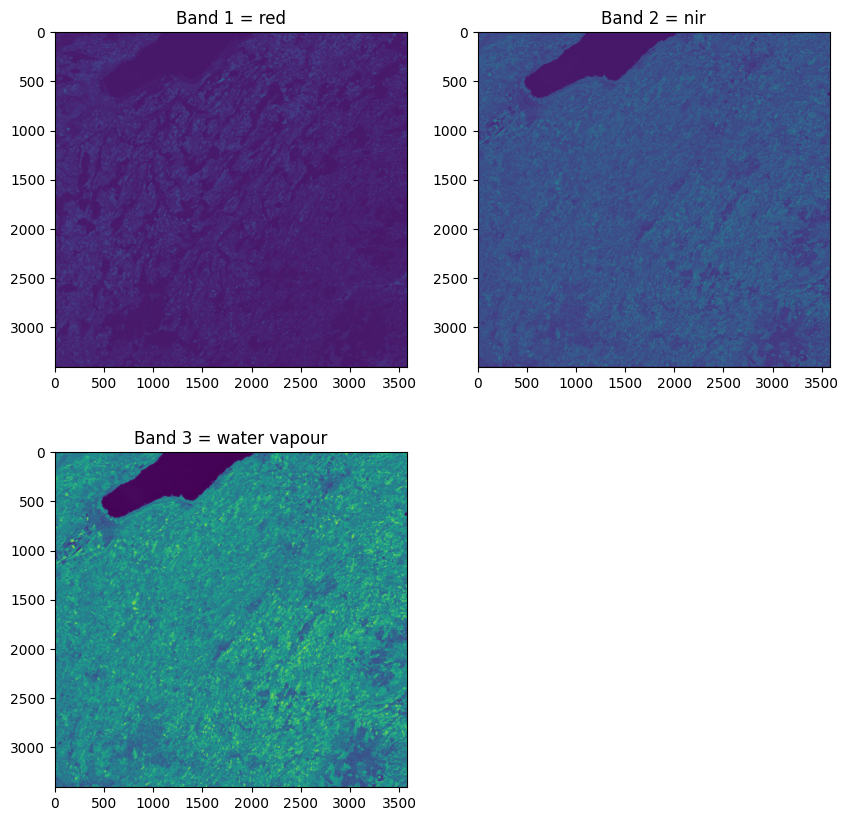

In [23]:
img  = rasterio.open("/content/drive/MyDrive/sparrso/merged.tif")


full_img = img.read()

band_counts = img.count
print("band_counts = ", band_counts)

img_band1 = img.read(1)
img_band2 = img.read(2)#
img_band3 = img.read(3)#
fig = plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_band1)
plt.title("Band 1 = red")
plt.subplot(2, 2, 2)
plt.imshow(img_band2)
plt.title("Band 2 = nir")
plt.subplot(2, 2, 3)
plt.imshow(img_band3)
plt.title("Band 3 = water vapour")

plt.show()




In [24]:
print(f"cordinated system {img.crs}")

cordinated system EPSG:32632


In [25]:
img.meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 3582,
 'height': 3408,
 'count': 3,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]'),
 'transform': Affine(10.0, 0.0, 314820.0,
        0.0, -10.0, 5190720.0)}

In [26]:
full_img.max()

np.uint16(17211)

In [27]:
print("geotransform", img.transform)

geotransform | 10.00, 0.00, 314820.00|
| 0.00,-10.00, 5190720.00|
| 0.00, 0.00, 1.00|


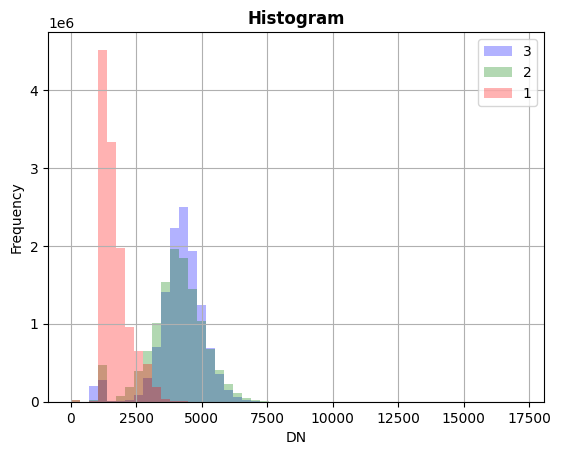

In [28]:
rasterio.plot.show_hist(full_img, bins=50, histtype='stepfilled', lw=0.0, stacked=False, alpha=0.3)

In [29]:
red = img.read(1).astype('float32')
nir = img.read(2).astype('float32')
valid = (red > 0) & (nir > 0)
ndvi = np.where(valid, (nir - red) / (nir + red), np.nan)

/tmp/ipykernel_1912/2706365688.py:4: RuntimeWarning: invalid value encountered in divide
  ndvi = np.where(valid, (nir - red) / (nir + red), np.nan)


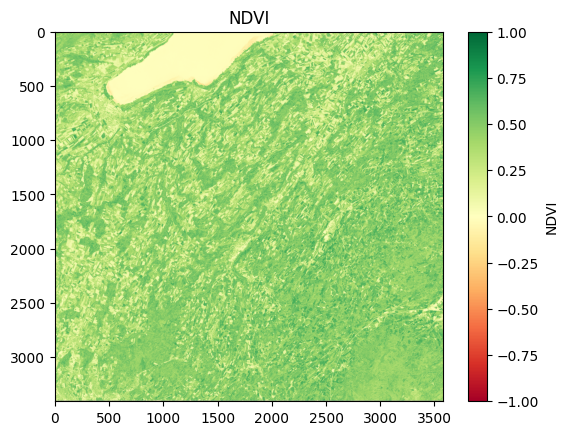

In [30]:
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title('NDVI')
plt.show()

In [31]:
print(red.dtype, nir.dtype)
print(red.min(), red.max(), nir.min(), nir.max())
print(ndvi.min(), ndvi.max(), np.nanmean(ndvi))

float32 float32
0.0 17211.0 0.0 16560.0
nan nan 0.400775


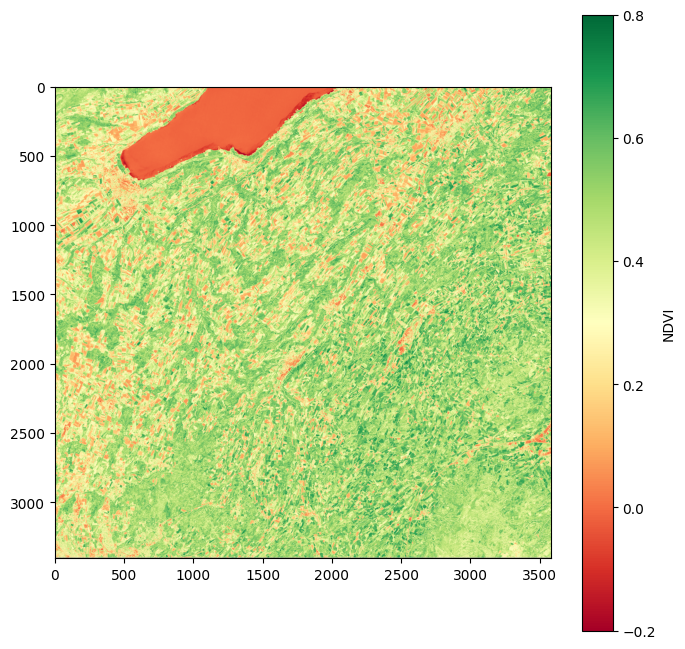

In [32]:
plt.figure(figsize=(8,8))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
plt.colorbar(label='NDVI')
plt.show()


In [33]:
print(img.count, img.descriptions)


3 (None, None, None)


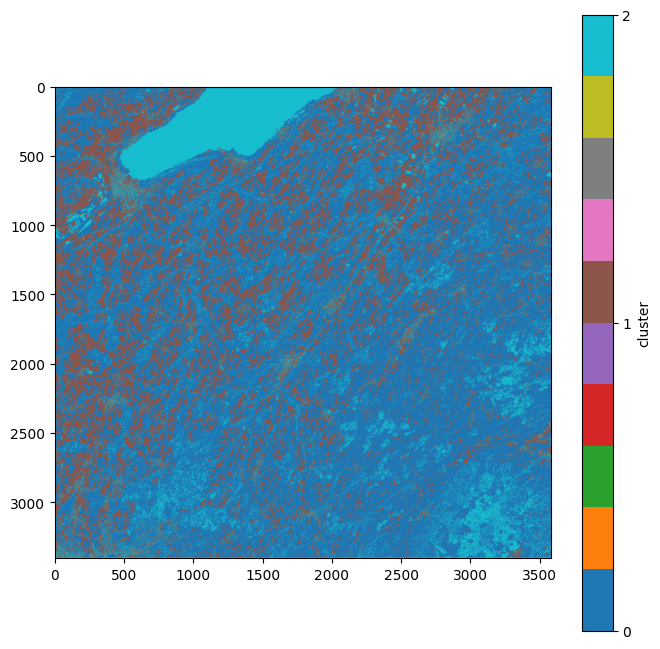

0 mean NDVI: 0.5 | share of pixels: 63%
1 mean NDVI: 0.21 | share of pixels: 23%
2 mean NDVI: 0.23 | share of pixels: 13%


In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

mask = ~np.isnan(ndvi)
X = np.dstack([red, nir, ndvi])[mask]
Xs = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xs[::20])
pred = km.predict(Xs)

labels = np.full(ndvi.shape, np.nan)
labels[mask] = pred

plt.figure(figsize=(8,8))
plt.imshow(labels, cmap='tab10')
plt.colorbar(ticks=range(3), label='cluster')
plt.savefig('clusters.png', dpi=150, bbox_inches='tight')
plt.show()

for k in range(3):
    print(k, 'mean NDVI:', round(float(X[pred==k, 2].mean()), 2),
          '| share of pixels:', f'{(pred==k).mean():.0%}')

In [35]:
from sklearn.metrics import silhouette_score

rng = np.random.default_rng(42)
idx = rng.choice(len(Xs), size=min(10000, len(Xs)), replace=False)
sample = Xs[idx]

for k in [2, 3, 4]:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(sample)
    print(k, round(silhouette_score(sample, km_k.labels_), 3))

2 0.464
3 0.468
4 0.404


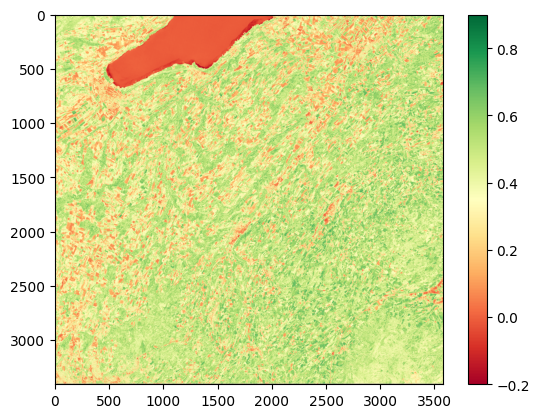

In [36]:
plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.9); plt.colorbar()
plt.savefig('ndvi.png', dpi=150, bbox_inches='tight'); plt.show()